In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

In [2]:
P=5
alpha=0.01
sigma=3.5e6
mur=4
mu0=4*np.pi*1e-7
POD=True
N=500
NPOD=50

In [3]:
# Select directory
# This is without POD
if POD==False:
    directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_"+str(N)+"_el_19567_ord_"+str(P)
else:
# This is with POD
    directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_"+str(N)+"_el_19567_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"
#    directory="Results/OCC_sphere_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_500_el_18237_ord_"+str(P)+"_POD_30_1e-6"
              #Results/OCC_sphere_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_500_el_18237_ord_3_POD_30_1e-6/

ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

print(xi)

[[    0.             0.             0.        ]
 [ 7915.92756124  7915.929208    7915.92686771]
 [26067.89603192 26067.90702513 26067.86128644]
 ...
 [    0.             0.             0.        ]
 [    0.             0.             0.        ]
 [    0.             0.             0.        ]]


In [4]:
# Exact poles, amp for conducting permable sphere
from scipy.optimize import fsolve
def exactpoleres(sigma,mu,alpha,N):
    poles=np.zeros((N))
    amp=np.zeros((N))
    beta=np.sqrt(sigma*mu)*alpha
    mur=mu/mu0

#   find solutions to fzerofun(deltan,mur) =0 
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    #print(Deltan)
    for n in range(1,N):
        # This is for mu=mu_0
        #deltan2=np.pi**2*n**2
        # This is for general mu
        deltan2=Deltan[n-1]**2
        poles[n]=-deltan2/beta**2
        # This is for mu =mu_0
        #amp[n]=6./(deltan2)
        # For general mu
        amp[n] = 6*mur/((mur+2)*(mur-1)+deltan2)
    return poles,amp

# Residual function to help find solutions to ((mur-1)+deltan2)*(tan deltan ) - (mur-1)*deltan = 0
def fzerofun(deltan,mur):
    return ((mur-1)+deltan**2)*np.tan(deltan) - (mur-1)*deltan



# Exact Step Function Response from a conducting non-permable sphere 
from scipy.optimize import fsolve
def derf(z):
    return 2/np.sqrt(np.pi)*np.exp(-z**2)
# Response from a step function
def exactA(t,sigma,mu,alpha,Npoles):
    mu0 = 4 * np.pi * (1e-7)
    mur=mu/mu0
    beta=np.sqrt(sigma*mu)*alpha
    x=np.sqrt(t)/beta
    T=t/beta**2
    # This is only valid for mur=1
    # Equation (11) Wait + Spies
    #A1=3*(T+1/3-2*np.sqrt(T/np.pi))
    # Method 1
    #for n in range(1,Npoles):
    #    derfn=derf(n/np.sqrt(T))
    #    erfcn=erfc(n/np.sqrt(T))
    #    A1+=-3*2*n*(np.sqrt(T)/n*derfn-2*erfcn)
    # Method 2 (not valid for small T)
    #A2=0.
    #for n in range(1,Npoles):
    #    A2+=6/np.pi**2*np.exp(-np.pi**2*n**2*T)/n**2 # eqn (22) Wait + Spies
    #   find solutions to fzerofun(deltan,mur) =0 

    # Only Method 2 works for permable case
    N=Npoles
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    A2=-2*(mur-1)/(mur+2)
    for n in range(1,Npoles):
        deltan2=Deltan[n-1]**2
        A2+=6*mur/((mur+2)*(mur-1)+ deltan2)*np.exp(-deltan2*T) # eqn (18) Wait + Spies
    A1=A2
    return A1,A2


# Response from a impulse function
def exactB(t,sigma,mu,alpha,Npoles):
    beta=np.sqrt(sigma*mu)*alpha
    x=np.sqrt(t)/beta
    T=t/beta**2
    # Only Method 2 works for permable case
    N=Npoles
    Deltan=fsolve(fzerofun, np.pi*np.linspace(1,N,N), args=(mur))
    Deltan=np.sort(Deltan)
    B2=0.
    for n in range(1,Npoles):
        deltan2=Deltan[n-1]**2
        B2+=-6*mur/((mur+2)*(mur-1)+ deltan2)*deltan2*np.exp(-deltan2*T) # eqn (21) Wait + Spies
    B1=B2
    return B1,B2    



In [5]:
import sympy as sym
def exact_sphere(alpha, epsilon, mur, sigma, omega):
    """
    Function to calculate the mpt for a sphere of radius alpha at radial frequency omega.
    Addapted from a Matlab function from Paul Ledger (exactsphererev5freqscan_nod.m).
    :param omega - Angular frequency rad/s
    :param epsilon - Permittivity:
    :param sigma - Conductivity S/m:
    :param mur - Relative Permeability:
    :param alpha - Sphere radius m:
    :return eig - Single unique eigenvalue of the mpt tensor for a sphere of radius alpha:
    """

    mu0 = 4 * np.pi * (1e-7)
    mu = mur * mu0
    k = np.sqrt((omega ** 2 * epsilon * sigma) + (mu * sigma * omega) * 1j)

    # Using sympy to try to avoid overflow errors.
    k *= alpha
    alpha = alpha

    js_0_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(1 / 2, k)
    js_1_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(3 / 2, k)
    js_2_kr = sym.sqrt(sym.pi / (2 * k)) * sym.besselj(5 / 2, k)
    mpt = (2 * np.pi * alpha ** 3) * (2 * (mu - mu0) * js_0_kr + (2 * mu + mu0) * js_2_kr) / (
        (mu + 2 * mu0) * js_0_kr + (mu - mu0) * js_2_kr)
    return complex(mpt.evalf())

[6.28318463e-06 6.28318462e-06 6.28318462e-06]


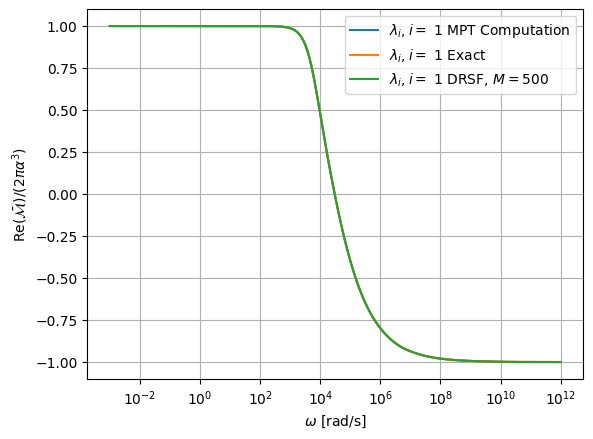

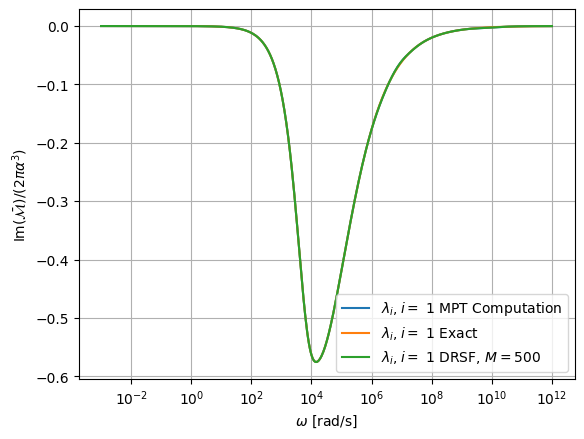

Error Measure 0.0004857593999160279


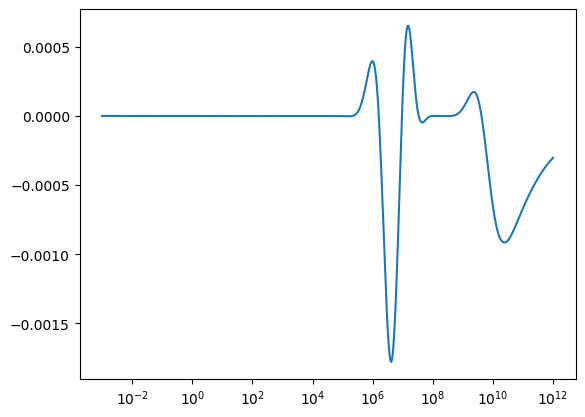

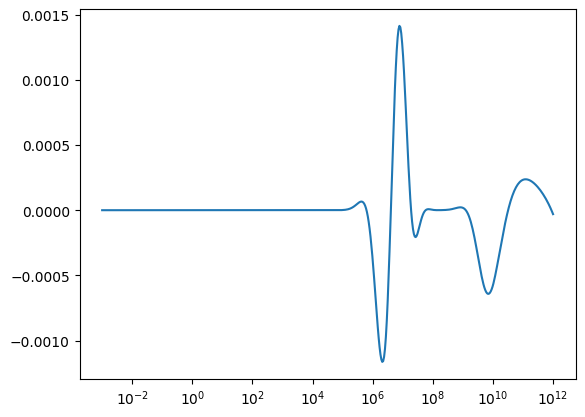

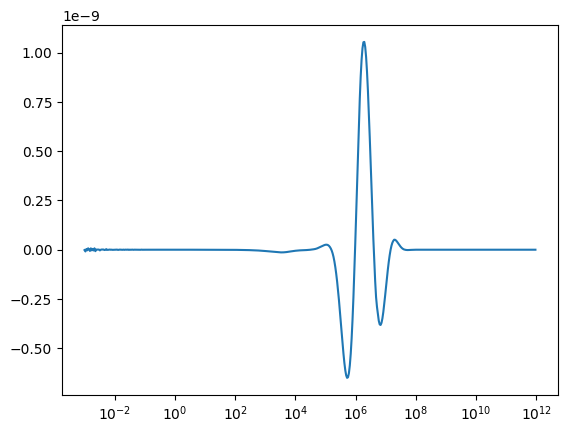

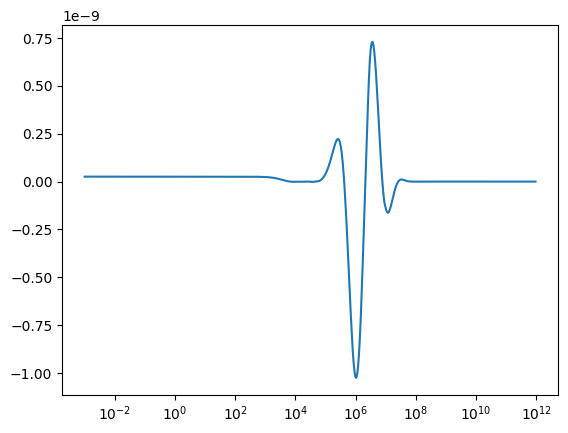

In [9]:
exactMPT=np.zeros(len(Omega),dtype=complex)
# Obtain exact MPT
n=0
for omega in Omega:
    exactMPT[n]=exact_sphere(alpha, 0, mur, sigma, omega)
    n+=1
# Obtain MPT from computed ck,xi
sMPT=np.zeros((len(Omega),3),dtype=complex)
dum,Q=np.linalg.eig(Minf)
lN0=np.diag(np.transpose(Q)@N0@Q)
print(lN0)
n=0
for omega in Omega:
    sMPT[n,:]=lN0[:]
    for k in range(1,len(xi)):
        s=1j*omega
        sk=-xi[k]
        sMPT[n,:]+=-ck[k,:]*(s/(s-sk))
    n=n+1


plt.figure(1)
plt.figure(2)
scale=2*np.pi*alpha**3
for i in range(1):
    plt.figure(1)
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,np.real(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    plt.semilogx(Omega,np.real(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" DRSF, $M=500$")
            
    plt.figure(2)
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,-np.imag(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    plt.semilogx(Omega,np.imag(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" DRSF, $M=500$")

plt.figure(1)
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Re$(\bar{\cal M})/(2\pi \alpha^3)$")
plt.legend()
plt.savefig("my_plots/sphere_mpt/computed_realmpt_M500.pdf")

plt.figure(2)
plt.legend()
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Im$(\bar{\cal M})/(2\pi \alpha^3)$")
plt.savefig("my_plots/sphere_mpt/computed_imagmpt_M500.pdf")
plt.show()



plt.figure(3)
plt.figure(4)
for i in range(1):
    plt.figure(3)
    plt.semilogx(Omega,np.real(Eigenvalues[:,i]-exactMPT)/np.abs(exactMPT),label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
   
            
    plt.figure(4)
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i]-exactMPT)/np.abs(exactMPT),label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")

print("Error Measure",np.linalg.norm(Eigenvalues[:,0]-exactMPT)/np.linalg.norm(exactMPT))

plt.figure(5)
plt.figure(6)
Nomega=len(Omega)
dexactMPT=np.zeros(Nomega-1,dtype=complex)
dEigenvalues=np.zeros(Nomega-1,dtype=complex)
for i in range(Nomega-1):
    dexactMPT[i]=(exactMPT[i+1]-exactMPT[i])/(Omega[i+1]-Omega[i])
    dEigenvalues[i]=(Eigenvalues[i+1,0]-Eigenvalues[i,0])/(Omega[i+1]-Omega[i])
    
for i in range(1):

    plt.figure(5)
    plt.semilogx(Omega[0:-1],np.real(dexactMPT[:]-dEigenvalues[:])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" dMPT exact")
    #plt.semilogx(Omega[0:-1],np.real(dEigenvalues[:])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" dMPT Computation")   
            
    plt.figure(6)
    plt.semilogx(Omega[0:-1],np.imag(dexactMPT[:]-dEigenvalues[:])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+"dMPT exact")
    #plt.semilogx(Omega[0:-1],np.imag(dEigenvalues[:])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" dMPT Computation")               
                 



[       0.            -7892.91669004   -25374.73864028   -53653.53300996
   -93022.35270049  -143562.46349437  -205300.95530173  -278248.54603154
  -362410.08502918  -457788.00535374  -564383.63050264  -682197.72835656
  -811230.7684197   -951483.05049457 -1102954.77313149 -1265646.07197195
 -1439557.04219249 -1624687.75214839 -1821038.25194479 -2028608.57897871] [0.         0.75268274 0.38313215 0.2135379  0.13211969 0.08870219
 0.06329376 0.04728874 0.03660852 0.02914805 0.02374086 0.01970144
 0.01660679 0.01418493 0.01225478 0.01069213 0.00940955 0.00834405
 0.0074494  0.00669099]
500
500


/tmp/user/10925/ipykernel_1858923/4150530717.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_1858923/4150530717.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(polesexact)),ckexact)


<Figure size 640x480 with 0 Axes>

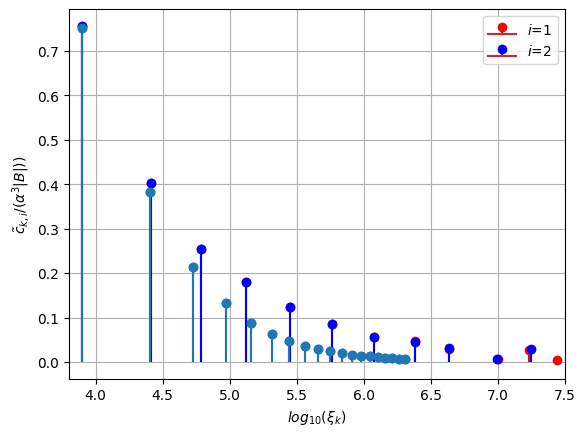

In [7]:

# Compare the modes and amplitudes
Npoles=20
polesexact,ckexact=exactpoleres(sigma,mur*mu0,alpha,Npoles)
print(polesexact,ckexact)
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(2):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    print(nfound)
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
    plt.stem(np.log10(np.abs(polesexact)),ckexact)
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B|))$')

plt.grid()
plt.xlim(3.8,7.5)
plt.legend()





<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_1858923/3432435502.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))


Text(0, 0.5, '-$\\lambda_i/(2\\pi\\alpha^3)$')

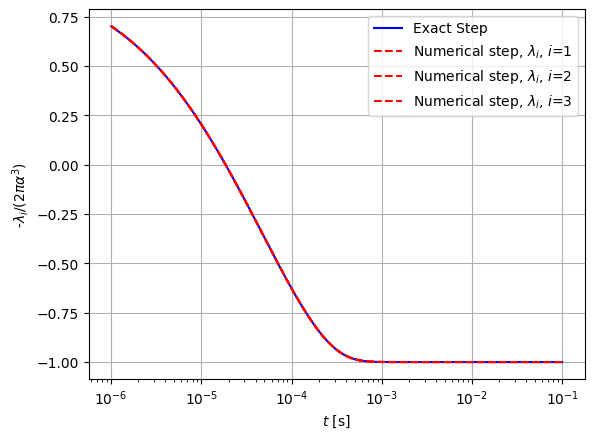

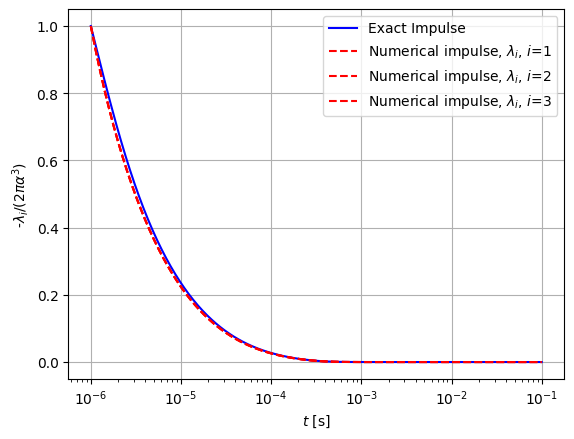

In [8]:
Npoles=20
# Get the exact td step response (Method 2)
_, A2 = exactA(time, sigma, mur*mu0, alpha, Npoles)
l_td_exact_step = A2

# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=1
plt.semilogx(time, l_td_exact_step /scale , 'b-', label="Exact Step")
scale=2*np.pi*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,"r--",label="Numerical step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(2\pi\alpha^3)$")



_, B2 = exactB(time, sigma, mur*mu0, alpha, Npoles)
l_td_exact_impulse = B2

plt.figure(2)
scale=l_td_exact_impulse[0]
plt.semilogx(time, l_td_exact_impulse / scale, 'b-', label="Exact Impulse")
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,"r--",label=r"Numerical impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(2\pi\alpha^3)$")

In [9]:
from Functions.Core_Spectrum.getimpulse_step import *


In [10]:
# remove scaling
TensorArrayn=TensorArray#/(2*np.pi*alpha**3)
Minfn = Minf #/(2*np.pi*alpha**3)

#Minfn=-1*np.eye(3)
xi_iter, ck_iter, Nfound_iter = PolesandAmp(Omega,np.conj(TensorArrayn),Minfn, Iterative_refine=True)
ck_iter=ck_iter#*(2*np.pi*alpha**3)

[-6.28318476e-06 -6.28318475e-06 -6.28318475e-06]
Estimated lambda parameter 1e-15
Found23terms
c=[-6.28577481e-06  4.72927868e-06  2.40872903e-06  1.35287428e-06
  8.75742020e-07  6.34130794e-07  4.88679250e-07  4.29781477e-07
  3.78260008e-07  2.96653488e-07  2.62880029e-07  2.31502882e-07
  7.37364150e-08  1.22358844e-07  9.61076389e-08  5.39453717e-08
  3.32728093e-08  3.20062447e-08  2.36952163e-08  1.47163280e-08
  1.62712150e-08  1.14242647e-08  2.91314440e-09]
xi=[0.00000000e+00 7.89294746e+03 2.53797291e+04 5.37885738e+04
 9.47643190e+04 1.53676376e+05 2.39096020e+05 3.73109195e+05
 6.11599505e+05 1.06682535e+06 1.94284045e+06 3.39812945e+06
 5.70854332e+06 1.47112648e+07 2.08262325e+07 5.70238157e+07
 9.63077464e+07 1.96689144e+08 4.49387477e+08 1.06105790e+09
 4.37051367e+09 9.70442216e+09 1.00000000e+12]
Estimated lambda parameter 1e-15
Found21terms
c=[-6.30474069e-06  4.72927955e-06  2.40874643e-06  1.35242431e-06
  8.67774290e-07  5.82459068e-07  4.34318853e-07  4.6126600

/tmp/user/10925/ipykernel_2929381/3591491114.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_2929381/3591491114.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(polesexact)),ckexact, label=r"Exact")
/tmp/user/10925/ipykernel_2929381/3591491114.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
/tmp/user/10925/ipykernel_2929381/3591491114.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(polesexact)),ckexact, label=r"Exact")


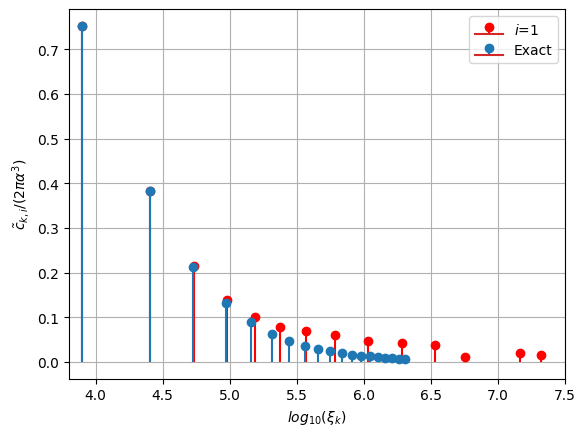

<Figure size 640x480 with 0 Axes>

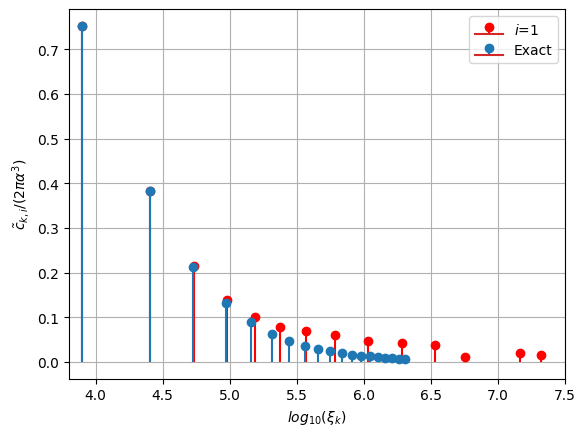

In [11]:
plt.figure()
col=['r','b','x']
plt.figure(1)
for i in range(1):
    nfound=len(xi_iter[:,i])
    ckp=ck_iter[0:nfound,i]
    xip=xi_iter[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
    plt.stem(np.log10(np.abs(polesexact)),ckexact, label=r"Exact")
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (2 \pi \alpha^3 )$')

plt.grid()
plt.xlim(3.8,7.5)
plt.legend()
#plt.savefig("my_plots/sphere_mpt/modes_amp_iter_refine_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_50_1e-6.pdf")

plt.figure()
col=['r','b','x']
plt.figure()
for i in range(1):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*2*np.pi),col[i],label=r"$i$="+str(i+1))
    plt.stem(np.log10(np.abs(polesexact)),ckexact, label=r"Exact")
    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (2 \pi \alpha^3 )$')
    

plt.grid()
plt.xlim(3.8,7.5)
plt.legend()
plt.savefig("my_plots/sphere_mpt/modes_amp_nnls_Nfreq_"+str(N)+"_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
plt.show()

[6.28318463e-06 6.28318462e-06 6.28318462e-06]


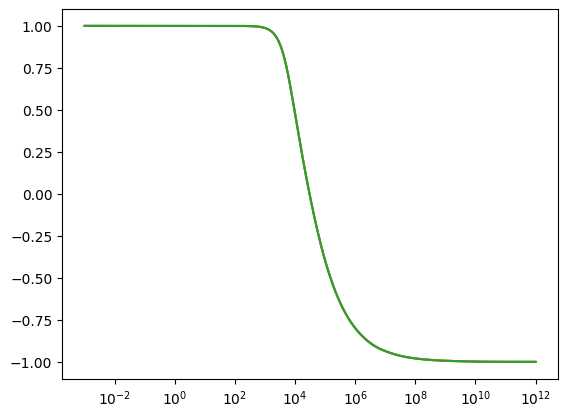

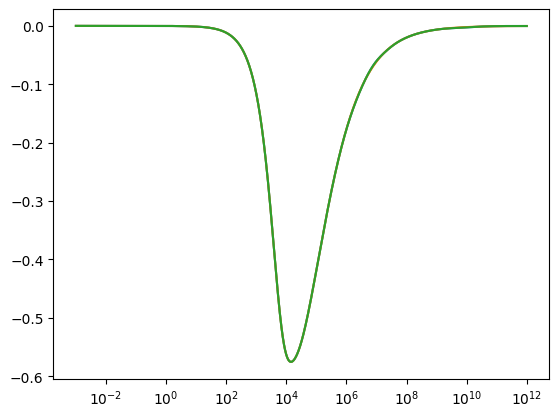

In [12]:
# Obtain MPT from computed ck,xi
sMPT=np.zeros((len(Omega),3),dtype=complex)
dum,Q=np.linalg.eig(Minf)
lN0=np.diag(np.transpose(Q)@N0@Q)
print(lN0)
n=0
for omega in Omega:
    sMPT[n,:]=lN0[:]
    for k in range(1,len(xi)):
        s=1j*omega
        sk=-xi_iter[k]
        sMPT[n,:]+=-ck_iter[k,:]*(s/(s-sk))
    n=n+1


plt.figure(1)
plt.figure(2)
scale=2*np.pi*alpha**3
for i in range(1):
    plt.figure(1)
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,np.real(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    plt.semilogx(Omega,np.real(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" DRSF, $M=500$")
            
    plt.figure(2)
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,-np.imag(exactMPT)/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Exact")
    plt.semilogx(Omega,np.imag(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" DRSF, $M=500$")

In [13]:
P=5
alpha=0.01
sigma=3.5e6
mur=4
mu0=4*np.pi*1e-7
N=100
NPOD=50
# Select directory
directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_"+str(N)+"_el_19567_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

ck100=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi100=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega100=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArray100= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues100=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf100= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0100= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

N=3000
NPOD=50
# Select directory
directory="Results/OCC_sphere_prism_4/al_0.01_mu_4_sig_3.5e6/1e-3-1e12_"+str(N)+"_el_19567_ord_"+str(P)+"_POD_"+str(NPOD)+"_1e-6"

ck3000=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi3000=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega3000=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
TensorArray3000= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues3000=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf3000= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N03000= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')


In [14]:
# DRSF representations for 100 and 3000 freqs
sMPT100=np.zeros((len(Omega100),3),dtype=complex)
lN0100,dum=np.linalg.eig(N0100)
n=0
for omega in Omega100:
    sMPT100[n,:]=lN0100[:]
    for k in range(1,len(xi100[:,0])):
        s=1j*omega
        sk=-xi100[k,0]
        sMPT100[n,:]+=-ck100[k,:]*(s/(s-sk))
    n=n+1

sMPT3000=np.zeros((len(Omega3000),3),dtype=complex)
lN03000,dum=np.linalg.eig(N03000)
n=0
for omega in Omega3000:
    sMPT3000[n,:]=lN03000[:]
    for k in range(1,len(xi3000[:,0])):
        s=1j*omega
        sk=-xi3000[k,0]
        sMPT3000[n,:]+=-ck3000[k,:]*(s/(s-sk))
    n=n+1


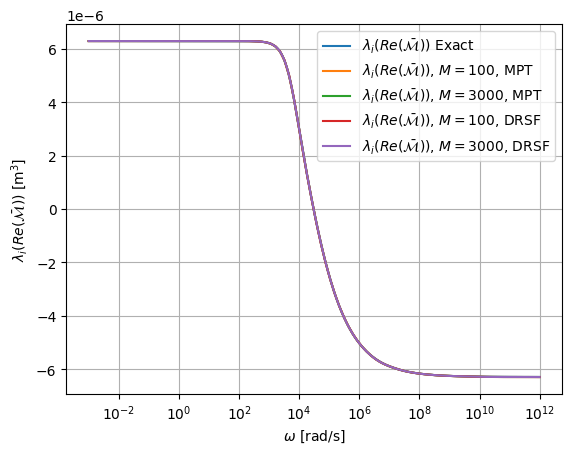

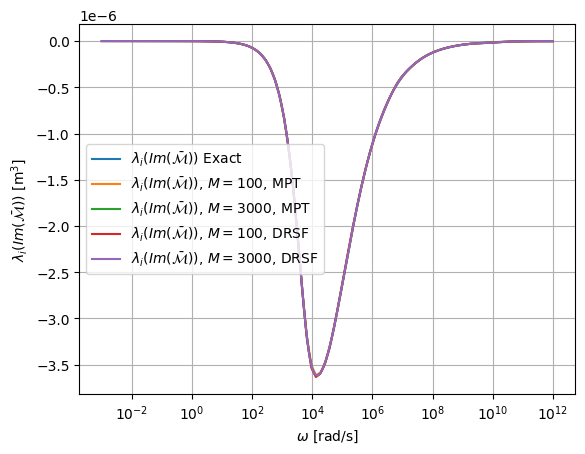

In [15]:
plt.figure(1)
plt.semilogx(Omega,np.real(exactMPT),label=r"$\lambda_i(Re(\bar{\cal M}))$ Exact")
plt.semilogx(Omega100,np.real(Eigenvalues100[:,0]),label=r"$\lambda_i(Re(\bar{\cal M}))$, $M=100$, MPT")
plt.semilogx(Omega3000,np.real(Eigenvalues3000[:,0]),label=r"$\lambda_i(Re(\bar{\cal M}))$, $M=3000$, MPT")
plt.semilogx(Omega100,np.real(sMPT100[:,0]),label=r"$\lambda_i(Re(\bar{\cal M}))$, $M=100$, DRSF")
plt.semilogx(Omega3000,np.real(sMPT3000[:,0]),label=r"$\lambda_i(Re(\bar{\cal M}))$, $M=3000$, DRSF")
plt.legend()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$\lambda_i(Re(\bar{\cal M}))$ [m$^3$]")
plt.grid()
plt.savefig("my_plots/sphere_mpt/CompareMPT_with_exact_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")


plt.figure(2)
plt.semilogx(Omega,-np.imag(exactMPT),label=r"$\lambda_i(Im(\bar{\cal M}))$ Exact")
plt.semilogx(Omega100,-np.imag(Eigenvalues100[:,0]),label=r"$\lambda_i(Im(\bar{\cal M}))$, $M=100$, MPT")
plt.semilogx(Omega3000,-np.imag(Eigenvalues3000[:,0]),label=r"$\lambda_i(Im(\bar{\cal M}))$, $M=3000$, MPT")
plt.semilogx(Omega100,np.imag(sMPT100[:,0]),label=r"$\lambda_i(Im(\bar{\cal M}))$, $M=100$, DRSF")
plt.semilogx(Omega3000,np.imag(sMPT3000[:,0]),label=r"$\lambda_i(Im(\bar{\cal M}))$, $M=3000$, DRSF")
plt.legend()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$\lambda_i(Im(\bar{\cal M}))$ [m$^3$]")
plt.grid()
plt.savefig("my_plots/sphere_mpt/CompareMPT_with_exact_p_"+str(P)+"_POD_"+str(NPOD)+"_1e-6.pdf")
plt.show()
